##### Multi-line chart
Data vis 2 on another notebook kasi mas madali siguro toh irun

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

# Setup REF :: From Live Coding Kit
try:
    import numpy as np
except ImportError as e:
    raise ImportError(
        "This notebook requires numpy. Run the install cell above (or `python -m pip install -r requirements.txt`), then restart the kernel."
    ) from e

try:
    import pandas as pd
except ImportError as e:
    raise ImportError(
        "This notebook requires pandas. Run the install cell above (or `python -m pip install -r requirements.txt`), then restart the kernel."
    ) from e

try:
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError(
        "This notebook requires matplotlib. Run the install cell above (or `python -m pip install -r requirements.txt`), then restart the kernel."
    ) from e

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "font.size": 11,
    }
)

# Import Data and Set Up Output Folder REF :: From Live Coding Kit

OUT_DIR = Path("notebooks/outputs") if Path("notebooks").is_dir() else Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Outputs will be written to:", OUT_DIR.resolve())

# Locate the class dataset regardless of whether you're running from repo root or `notebooks/`.
DATA_CANDIDATES = [
    Path("202512_CombinedData.csv"),
    Path("DATA101 Notebook\202512_CombinedData.csv"),
]
for _p in DATA_CANDIDATES:
    if _p.exists():
        DATA_PATH = _p
        break
else:
    raise FileNotFoundError(
        "Could not find data-task-abstraction-dataset.csv. "
        "Expected it in `notebooks/` (recommended) or the current folder."
    )

df = pd.read_csv(DATA_PATH)

Outputs will be written to: C:\Users\kiwib\Desktop\DATA101 Notebook\outputs


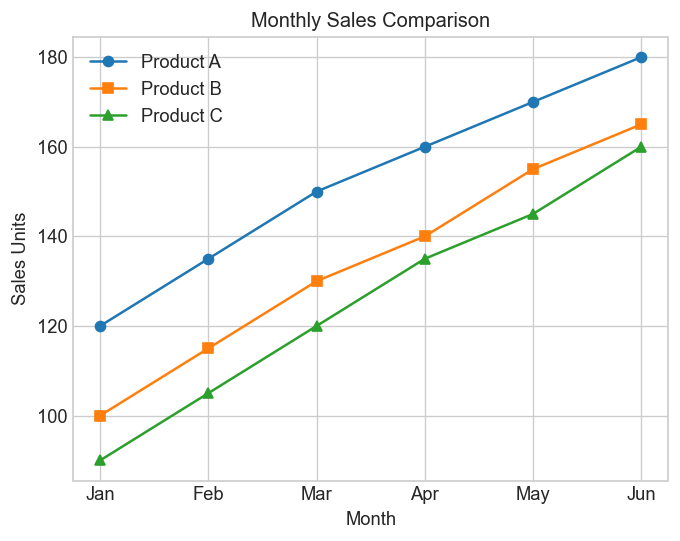

In [ ]:
# reference

# Sample data
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales_A = [120, 135, 150, 160, 170, 180]
sales_B = [100, 115, 130, 140, 155, 165]
sales_C = [90, 105, 120, 135, 145, 160]

# Plot multiple lines
plt.plot(months, sales_A, marker='o', label="Product A")
plt.plot(months, sales_B, marker='s', label="Product B")
plt.plot(months, sales_C, marker='^', label="Product C")

# Add chart details
plt.title("Monthly Sales Comparison")
plt.xlabel("Month")
plt.ylabel("Sales Units")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 102669 entries, 0 to 102668
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   datetime          102669 non-null  str    
 1   main.aqi          102669 non-null  float64
 2   components.co     102669 non-null  float64
 3   components.no     102669 non-null  float64
 4   components.no2    102669 non-null  float64
 5   components.o3     102669 non-null  float64
 6   components.so2    102669 non-null  float64
 7   components.pm2_5  102669 non-null  float64
 8   components.pm10   102669 non-null  float64
 9   components.nh3    102669 non-null  float64
 10  city_name         102669 non-null  str    
dtypes: float64(9), str(2)
memory usage: 8.6 MB


In [ ]:

# Assuming df is your DataFrame
# Convert datetime column to actual datetime type

# Pivot the data so each city gets its own column
pivot_df = df.pivot(index='datetime', columns='city_name', values='main.aqi')

# Plot all cities as separate lines
pivot_df.plot(figsize=(12,6))

# Add chart details
plt.title("Air Quality Index (AQI) by City Over Time")
plt.xlabel("Date")
plt.ylabel("Main AQI")
plt.legend(title="City")
plt.grid(True)

plt.show()